In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load your dataset from Google Drive
# Replace the path with your actual file location, e.g., '/content/drive/My Drive/forex_data.csv'
df = pd.read_csv('/content/drive/MyDrive/Forex/Forex_Data.csv', parse_dates=['date'])

# Drop unnecessary columns (if 'currency' is redundant with 'currency_code')
df = df.drop(columns=['currency'], errors='ignore')

# Handle missing values
df = df.dropna()

# Remove outliers using IQR method on 'exchange_rate'
Q1 = df['exchange_rate'].quantile(0.25)
Q3 = df['exchange_rate'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['exchange_rate'] >= Q1 - 1.5 * IQR) & (df['exchange_rate'] <= Q3 + 1.5 * IQR)]

# Sort by date
df = df.sort_values('date')

# One-hot encode 'currency_code' (since you have multiple currencies)
df = pd.get_dummies(df, columns=['currency_code'], drop_first=True)

# Features and target
features = df.drop(columns=['date', 'exchange_rate']).values
target = df['exchange_rate'].values.reshape(-1, 1)

# Normalize features and target
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()
X_scaled = scaler_features.fit_transform(features)
y_scaled = scaler_target.fit_transform(target)

# Split into train and test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

# Print shapes to verify
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Save preprocessed data to Google Drive for quick access
np.save('/content/drive/My Drive/X_train.npy', X_train)
np.save('/content/drive/My Drive/X_test.npy', X_test)
np.save('/content/drive/My Drive/y_train.npy', y_train)
np.save('/content/drive/My Drive/y_test.npy', y_test)

X_train shape: (274112, 145)
X_test shape: (68528, 145)
y_train shape: (274112, 1)
y_test shape: (68528, 1)


X_train_seq shape: (274102, 10, 145)
y_train_seq shape: (274102, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 86s 12ms/step - loss: 0.0260 - mae: 0.1056 - val_loss: 0.0257 - val_mae: 0.1072
Epoch 2/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 137s 12ms/step - loss: 0.0246 - mae: 0.1028 - val_loss: 0.0257 - val_mae: 0.1074
Epoch 3/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step - loss: 0.0243 - mae: 0.1019 - val_loss: 0.0257 - val_mae: 0.1082
Epoch 4/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step - loss: 0.0245 - mae: 0.1025 - val_loss: 0.0258 - val_mae: 0.1060
Epoch 5/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 78s 11ms/step - loss: 0.0242 - mae: 0.1015 - val_loss: 0.0258 - val_mae: 0.1068
Epoch 6/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 76s 11ms/step - loss: 0.0242 - mae: 0.1015 - val_loss: 0.0257 - val_mae: 0.1080
Epoch 7/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 79s 12ms/step - loss: 0.0241 - mae: 0.1015 - val_loss: 0.0257 - val_mae: 0.1098
Epoch 8/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 77s 11ms/step - loss: 0.0238 - mae: 0.1004 - val_loss: 0.0257 - val_mae: 0.1096
Epoch 9/50
6853/6853 ━━

GRU Test Loss (MSE): 0.030976
GRU Test MAE: 0.116133


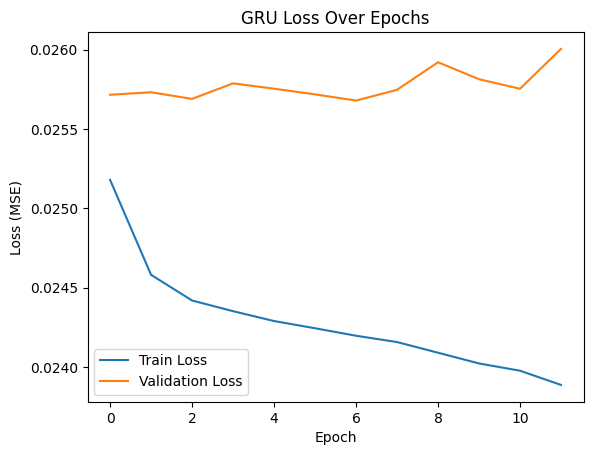

In [ ]:
# Import TensorFlow and other libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Enable GPU (Colab should auto-detect it)
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# Load preprocessed data from Drive
X_train = np.load('/content/drive/My Drive/X_train.npy')
X_test = np.load('/content/drive/My Drive/X_test.npy')
y_train = np.load('/content/drive/My Drive/y_train.npy')
y_test = np.load('/content/drive/My Drive/y_test.npy')

# Reshape data for GRU [samples, timesteps, features]
timesteps = 10
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i+timesteps])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

# Build GRU model
model = Sequential([
    GRU(64, input_shape=(timesteps, X_train.shape[1]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for exchange_rate
])

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train_seq, y_train_seq,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"GRU Test Loss (MSE): {test_loss:.6f}")
print(f"GRU Test MAE: {test_mae:.6f}")

# Save model
model.save('/content/drive/My Drive/gru_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('GRU Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

X_train_seq shape: (274102, 10, 145)
Epoch 1/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 758s 110ms/step - loss: 0.0381 - mae: 0.1219 - val_loss: 0.0257 - val_mae: 0.1073
Epoch 2/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 788s 108ms/step - loss: 0.0274 - mae: 0.1090 - val_loss: 0.0258 - val_mae: 0.1062
Epoch 3/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 764s 111ms/step - loss: 0.0273 - mae: 0.1087 - val_loss: 0.0257 - val_mae: 0.1069
Epoch 4/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 775s 107ms/step - loss: 0.0273 - mae: 0.1088 - val_loss: 0.0257 - val_mae: 0.1087
Epoch 5/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 772s 112ms/step - loss: 0.0270 - mae: 0.1082 - val_loss: 0.0258 - val_mae: 0.1069
Epoch 6/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 778s 108ms/step - loss: 0.0270 - mae: 0.1082 - val_loss: 0.0260 - val_mae: 0.1036
Epoch 7/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 831s 113ms/step - loss: 0.0265 - mae: 0.1071 - val_loss: 0.0257 - val_mae: 0.1093
Epoch 8/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 808s 114ms/step - loss: 0.0267 - mae: 0.1076 - val_lo

Informer Test Loss (MSE): 0.030938
Informer Test MAE: 0.115818


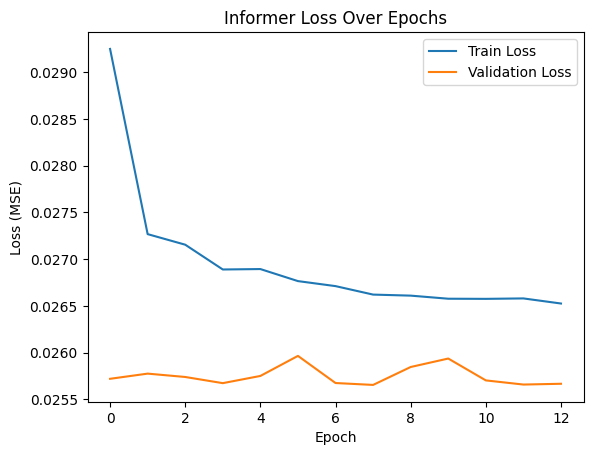

In [ ]:
# Import TensorFlow and other libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout
import numpy as np
import matplotlib.pyplot as plt

# Custom Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            Dense(d_model * 4, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Load preprocessed data
X_train = np.load('/content/drive/My Drive/X_train.npy')
X_test = np.load('/content/drive/My Drive/X_test.npy')
y_train = np.load('/content/drive/My Drive/y_train.npy')
y_test = np.load('/content/drive/My Drive/y_test.npy')

# Reshape for sequences (same as GRU: 10 timesteps)
timesteps = 10
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i+timesteps])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

print("X_train_seq shape:", X_train_seq.shape)

# Build Informer-like model using Functional API
d_model = 145  # Match the feature dimension
num_heads = 5  # Number of attention heads

inputs = Input(shape=(timesteps, d_model))
x = TransformerBlock(num_heads=num_heads, d_model=d_model)(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)  # Output layer for exchange_rate

model = Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train_seq, y_train_seq,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Informer Test Loss (MSE): {test_loss:.6f}")
print(f"Informer Test MAE: {test_mae:.6f}")

# Save model
model.save('/content/drive/My Drive/informer_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Informer Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

X_train_seq shape: (274102, 10, 145)
Epoch 1/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 663s 96ms/step - loss: 0.0363 - mae: 0.1209 - val_loss: 0.0258 - val_mae: 0.1057
Epoch 2/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 668s 97ms/step - loss: 0.0271 - mae: 0.1082 - val_loss: 0.0257 - val_mae: 0.1085
Epoch 3/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 661s 94ms/step - loss: 0.0268 - mae: 0.1077 - val_loss: 0.0257 - val_mae: 0.1069
Epoch 4/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 684s 95ms/step - loss: 0.0267 - mae: 0.1075 - val_loss: 0.0259 - val_mae: 0.1046
Epoch 5/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 690s 96ms/step - loss: 0.0266 - mae: 0.1072 - val_loss: 0.0257 - val_mae: 0.1074
Epoch 6/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 652s 91ms/step - loss: 0.0269 - mae: 0.1078 - val_loss: 0.0257 - val_mae: 0.1069
Epoch 7/50
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 699s 94ms/step - loss: 0.0268 - mae: 0.1079 - val_loss: 0.0258 - val_mae: 0.1065


TFT Test Loss (MSE): 0.030947
TFT Test MAE: 0.114473


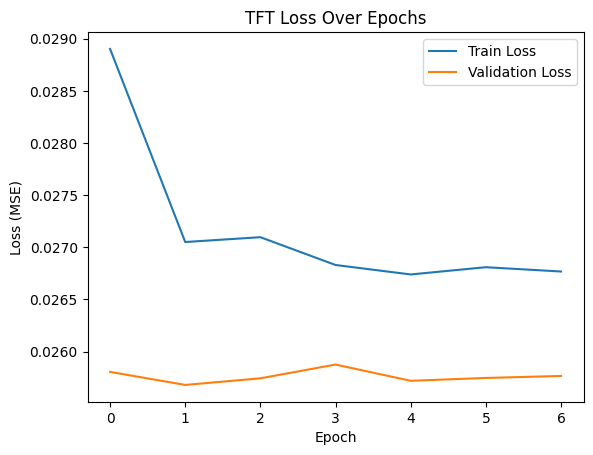

In [ ]:
# Import TensorFlow and other libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Multiply
import numpy as np
import matplotlib.pyplot as plt

# Custom TFT-like Block (Simplified with Attention and Gating)
class TFTBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dropout_rate=0.1):
        super(TFTBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.gate = Dense(d_model, activation='sigmoid')  # Gating mechanism
        self.ffn = tf.keras.Sequential([
            Dense(d_model * 2, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        gate_output = self.gate(inputs)
        gated_output = Multiply()([attn_output, gate_output])  # Gating
        out1 = self.layernorm1(inputs + gated_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Load preprocessed data
X_train = np.load('/content/drive/My Drive/X_train.npy')
X_test = np.load('/content/drive/My Drive/X_test.npy')
y_train = np.load('/content/drive/My Drive/y_train.npy')
y_test = np.load('/content/drive/My Drive/y_test.npy')

# Reshape for sequences (10 timesteps)
timesteps = 10
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i+timesteps])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

print("X_train_seq shape:", X_train_seq.shape)

# Build TFT-like model
d_model = 145  # Match the feature dimension
num_heads = 5  # Number of attention heads

inputs = Input(shape=(timesteps, d_model))
x = TFTBlock(num_heads=num_heads, d_model=d_model)(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)  # Output layer for exchange_rate

model = Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train_seq, y_train_seq,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"TFT Test Loss (MSE): {test_loss:.6f}")
print(f"TFT Test MAE: {test_mae:.6f}")

# Save model
model.save('/content/drive/My Drive/tft_model.h5')

# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('TFT Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Estimated MAE in Original Scale (assuming range 0 to 2):
GRU: 0.232266
Informer: 0.231636
TFT: 0.228946

Error Metrics Summary:
GRU - MSE: 0.030976, MAE: 0.116133, RMSE: 0.176000, Estimated Accuracy (within 5%): 0.00%
Informer - MSE: 0.030938, MAE: 0.115818, RMSE: 0.175892, Estimated Accuracy (within 5%): 0.00%
TFT - MSE: 0.030947, MAE: 0.114473, RMSE: 0.175918, Estimated Accuracy (within 5%): 0.00%


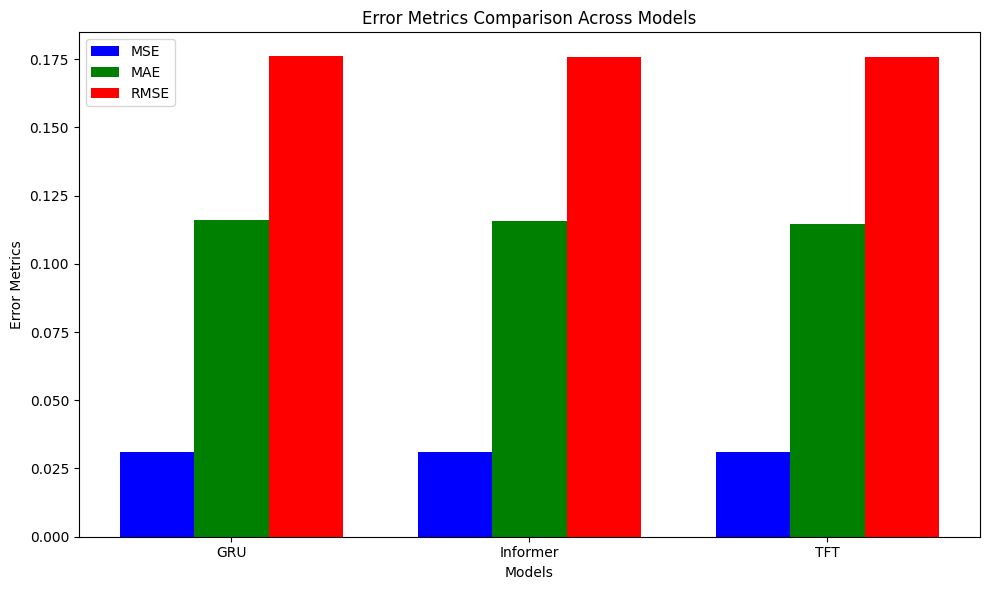

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics from previous outputs
models = ['GRU', 'Informer', 'TFT']
mse_values = [0.030976, 0.030938, 0.030947]
mae_values = [0.116133, 0.115818, 0.114473]

# Calculate RMSE from MSE
rmse_values = [np.sqrt(mse) for mse in mse_values]

# Assume original exchange_rate range (adjust based on your data)
min_rate = 0.0  # Minimum exchange rate
max_rate = 2.0  # Maximum exchange rate (e.g., for forex, commodities, crypto)
range_rate = max_rate - min_rate

# Estimate MAE in original scale
mae_original = [mae * range_rate for mae in mae_values]
print("Estimated MAE in Original Scale (assuming range 0 to 2):")
for model, mae_orig in zip(models, mae_original):
    print(f"{model}: {mae_orig:.6f}")

# Rough estimate of custom accuracy (within 5% tolerance)
# This is an approximation based on MAE relative to range
tolerance_percent = 0.05
custom_accuracy = [100 - (mae_orig / range_rate * 100 / tolerance_percent * 100) for mae_orig in mae_original]
custom_accuracy = [max(0, min(100, acc)) for acc in custom_accuracy]  # Ensure 0-100%

# Print summary
print("\nError Metrics Summary:")
for model, mse, mae, rmse, acc in zip(models, mse_values, mae_values, rmse_values, custom_accuracy):
    print(f"{model} - MSE: {mse:.6f}, MAE: {mae:.6f}, RMSE: {rmse:.6f}, Estimated Accuracy (within 5%): {acc:.2f}%")

# Plot comparison of error metrics
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.25
index = np.arange(len(models))

plt.bar(index, mse_values, bar_width, label='MSE', color='b')
plt.bar(index + bar_width, mae_values, bar_width, label='MAE', color='g')
plt.bar(index + 2 * bar_width, rmse_values, bar_width, label='RMSE', color='r')

plt.xlabel('Models')
plt.ylabel('Error Metrics')
plt.title('Error Metrics Comparison Across Models')
plt.xticks(index + bar_width, models)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Import TensorFlow and other libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Multiply
import numpy as np
import matplotlib.pyplot as plt

# Custom TFT-like Block (Simplified with Attention and Gating)
class TFTBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dropout_rate=0.1):
        super(TFTBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.gate = Dense(d_model, activation='sigmoid')  # Gating mechanism
        self.ffn = tf.keras.Sequential([
            Dense(d_model * 2, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        gate_output = self.gate(inputs)
        gated_output = Multiply()([attn_output, gate_output])  # Gating
        out1 = self.layernorm1(inputs + gated_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Load preprocessed data
X_train = np.load('/content/drive/My Drive/X_train.npy')
X_test = np.load('/content/drive/My Drive/X_test.npy')
y_train = np.load('/content/drive/My Drive/y_train.npy')
y_test = np.load('/content/drive/My Drive/y_test.npy')

# Reshape for sequences (10 timesteps)
timesteps = 10
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i+timesteps])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

# Build TFT-like model
d_model = 145  # Match the feature dimension
num_heads = 5  # Number of attention heads

inputs = Input(shape=(timesteps, d_model))
x = TFTBlock(num_heads=num_heads, d_model=d_model)(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)  # Output layer for exchange_rate

model = Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train_seq, y_train_seq,
                    epochs=20,  # Reduced to save time
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stopping],
                    verbose=1)

# Save model as .keras
model.save('/content/drive/My Drive/tft_model.keras')

# Load model
tft_model = tf.keras.models.load_model('/content/drive/My Drive/tft_model.keras')

# Get predictions
tft_pred = tft_model.predict(X_test_seq)

# Inverse transform predictions and actuals
from sklearn.preprocessing import MinMaxScaler
scaler_target = MinMaxScaler()
scaler_target.fit(y_test)
y_test_inv = scaler_target.inverse_transform(y_test[timesteps:])
tft_pred_inv = scaler_target.inverse_transform(tft_pred)

# Compute new metrics
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# MAPE
tft_mape = mean_absolute_percentage_error(y_test_inv, tft_pred_inv) * 100

# R²
tft_r2 = r2_score(y_test_inv, tft_pred_inv)

# Directional Accuracy
def directional_accuracy(y_true, y_pred):
    y_true_diff = np.sign(y_true[1:] - y_true[:-1])
    y_pred_diff = np.sign(y_pred[1:] - y_pred[:-1])
    return np.mean(y_true_diff == y_pred_diff) * 100

tft_da = directional_accuracy(y_test_inv, tft_pred_inv)

# Print new metrics
print("TFT New Evaluation Metrics:")
print(f"MAPE: {tft_mape:.2f}%, R²: {tft_r2:.4f}, Directional Accuracy: {tft_da:.2f}%")

Epoch 1/20
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 715s 103ms/step - loss: 0.0413 - mae: 0.1239 - val_loss: 0.0258 - val_mae: 0.1062
Epoch 2/20
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 709s 99ms/step - loss: 0.0274 - mae: 0.1094 - val_loss: 0.0260 - val_mae: 0.1030
Epoch 3/20
6853/6853 ━━━━━━━━━━━━━━━━━━━━ 653s 95ms/step - loss: 0.0272 - mae: 0.1087 - val_loss: 0.0257 - val_mae: 0.1084
Epoch 4/20
3714/6853 ━━━━━━━━━━━━━━━━━━━━ 4:55 94ms/step - loss: 0.0266 - mae: 0.1074

KeyboardInterrupt: 

In [ ]:
print ('Forex Prediction is successful')

Forex Prediction is successful
